In [1]:
print("Everything is okay!!!")

Everything is okay!!!


In [2]:
di = {"a":5}
di["a"] = 10
di

{'a': 10}

In [17]:
# Step 1: Define the state schema

# Define a TypedDict for defining state structure/schema
# and Annotated for type hinting with context-specific metadata
# add_messages to handle message passing in the graph - it merges two list of messages Reducer to manage state transitions

from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [6]:
# StateGraph, START, END to create the graph workflow
from langgraph.graph import StateGraph, START, END

In [18]:
# Load environment variables from a .env file
# As i will be using API keys from environment variables to run LLMs from LangChain openai and groq

import os
from dotenv import load_dotenv

load_dotenv()  # Load environment variables from .env file

# Now you can access your environment variables using os.getenv
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
print("Environment variables loaded successfully.")

Environment variables loaded successfully.


In [19]:
# load LLMs from langchain-groq

from langchain_groq import ChatGroq

groq_llm = ChatGroq(model = "llama-3.1-8b-instant", temperature=0.7)

groq_llm.invoke("Hey I am Anant and i like to develop AI models")  # Test the Groq LLM to ensure it's working

AIMessage(content='Nice to meet you, Anant. Developing AI models can be a fascinating and rewarding field. What specific areas of AI are you interested in, such as computer vision, natural language processing, or reinforcement learning? Or are you more interested in building chatbots or conversational interfaces?\n\nAlso, what level of experience do you have in AI development? Are you a beginner, intermediate, or advanced developer?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 47, 'total_tokens': 128, 'completion_time': 0.113849486, 'completion_tokens_details': None, 'prompt_time': 0.003492148, 'prompt_tokens_details': None, 'queue_time': 0.052024032, 'total_time': 0.117341634}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fb778-beaa-7680-95f8-284745f5100a-0', tool_calls=[], invalid_tool

In [20]:
# Create node
def Superbot(state:State):
    return {"messages": [groq_llm.invoke(state["messages"])]}

In [21]:
# StateGraph to define the workflow

workflow = StateGraph(State)

# add nodes to the workflow
workflow.add_node("Superbot", Superbot)

# define the edges with START and END
workflow.add_edge(START, "Superbot")
workflow.add_edge("Superbot", END)

# compile the workflow
compiled_workflow = workflow.compile()
print("Workflow compiled successfully.")

Workflow compiled successfully.


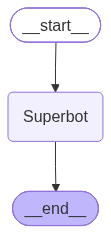

In [22]:
compiled_workflow

In [23]:
# invoke the workflow with initial messages
compiled_workflow.invoke({"messages":"What is Agentic AI?"})

{'messages': [HumanMessage(content='What is Agentic AI?', additional_kwargs={}, response_metadata={}, id='b8dc37fd-2021-4846-8ce4-1ba939babe44'),
  AIMessage(content='Agentic AI refers to a type of artificial intelligence (AI) that exhibits characteristics and behaviors similar to those of an autonomous agent. An autonomous agent is an entity that perceives its environment, has goals, and acts to achieve those goals in a way that is flexible and adaptable.\n\nAgentic AI systems possess abilities such as:\n\n1. **Self-awareness**: They have an understanding of their own existence and capabilities, allowing them to make decisions and take actions based on their own goals and motivations.\n2. **Goal-directed behavior**: They have specific objectives and can prioritize tasks to achieve those objectives.\n3. **Flexibility and adaptability**: They can adjust their actions and strategies in response to changing circumstances or new information.\n4. **Autonomy**: They can operate independently

In [14]:
mylist = [1,2,3,4,5,6]
mylist[-1]

6

In [24]:
while True:
    
    user_input = input("Enter query:")
    if user_input.lower() in ['bye', 'exit']:
        print("Conversation Stopped!!!")
        break
    response = compiled_workflow.invoke({
        "messages":user_input
    })
    
    print("User: ", user_input)
    print("AI Response:", response['messages'][-1].content)

User:  Hi i am anant
AI Response: Nice to meet you, Anant. Is there something I can help you with or would you like to chat?
User:  5+5
AI Response: 5 + 5 = 10
User:  tell me my name
AI Response: I don't have any information about your name. I'm a large language model, I don't have personal knowledge or access to personal data. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations.

If you'd like to share your name with me, I'd be happy to chat with you and use it in our conversation.
Conversation Stopped!!!
